# 03 Gap Diagnostics and Plotnine Figures

This notebook creates simple figures from measurement data dated **2026-05-29 onward only** and checks whether temperature patterns support overheating as a plausible explanation for missing data.

In [8]:
from pathlib import Path
import csv
import os
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

DATA_START_DATE = "20260529"
EXPECTED_INTERVAL_SECONDS = 20
GPS_STALE_THRESHOLD_MS = 120000
DATA_DIR = Path("..") / "test_data"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
MPLCONFIG_DIR = FIG_DIR / ".mplconfig"
MPLCONFIG_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR.resolve()))

from plotnine import *

print("pandas", pd.__version__)
print("figures", FIG_DIR.resolve())

pandas 3.0.3
figures C:\Users\jonmuell\Documents\GitHub\datalogger_esp8266\test_analysis\figures


In [9]:
def data_file_date(path: Path) -> str:
    match = re.fullmatch(r"data_(\d{8})\.csv", path.name)
    return match.group(1) if match else ""


def unique_headers(headers: list[str]) -> list[str]:
    total = Counter(headers)
    seen = defaultdict(int)
    out = []
    for header in headers:
        if total[header] == 1:
            out.append(header)
        else:
            bus = seen[header]
            out.append(f"{header}__bus{bus}")
            seen[header] += 1
    return out


def measurement_files(data_dir: Path = DATA_DIR, start_date: str = DATA_START_DATE) -> list[Path]:
    return sorted(
        path for path in data_dir.glob("data_*.csv")
        if data_file_date(path) and data_file_date(path) >= start_date
    )


def read_measurement_file(path: Path) -> pd.DataFrame:
    with path.open("r", encoding="utf-8", newline="") as f:
        headers = next(csv.reader(f))
    names = unique_headers(headers)
    df = pd.read_csv(
        path,
        names=names,
        skiprows=1,
        na_values=["", "nan", "NaN", "NAN"],
        keep_default_na=True,
        on_bad_lines="skip",
    )
    df.insert(0, "source_file", path.name)
    df.insert(1, "source_date", data_file_date(path))
    return df


files = measurement_files()
assert all(data_file_date(file) >= DATA_START_DATE for file in files)
data = pd.concat([read_measurement_file(file) for file in files], ignore_index=True)
data["timestamp_utc"] = pd.to_datetime(data["timestamp_utc"], errors="coerce")
if "timestamp_calc_utc" in data.columns:
    data["timestamp_calc_utc"] = pd.to_datetime(data["timestamp_calc_utc"], errors="coerce")
else:
    data["timestamp_calc_utc"] = pd.NaT
if "gps_time_fresh" in data.columns:
    data["gps_time_fresh_bool"] = pd.to_numeric(data["gps_time_fresh"], errors="coerce").fillna(1).astype(bool)
else:
    data["gps_time_fresh_bool"] = True
gps_age = pd.to_numeric(data["gps_age_ms"], errors="coerce") if "gps_age_ms" in data.columns else pd.Series(pd.NA, index=data.index, dtype="Float64")
data["gps_age_too_high"] = gps_age > GPS_STALE_THRESHOLD_MS
data["gps_time_stale"] = (~data["gps_time_fresh_bool"]) | data["gps_age_too_high"].fillna(False)
if "timestamp_calc_source" in data.columns:
    calc_source = data["timestamp_calc_source"].astype("string").str.lower()
else:
    calc_source = pd.Series(pd.NA, index=data.index, dtype="string")
boot_ms = pd.to_numeric(data.get("timestamp_boot_ms", data.get("uptime_ms", pd.Series(pd.NA, index=data.index))), errors="coerce")
data["analysis_time"] = data["timestamp_utc"]
groups = data.groupby("boot_id", dropna=False) if "boot_id" in data.columns else [(None, data)]
for _, group in groups:
    fresh = (~group["gps_time_stale"]) & group["timestamp_utc"].notna() & boot_ms.loc[group.index].notna()
    if not fresh.any():
        continue
    base_idx = fresh[fresh].index[-1]
    base_utc = data.at[base_idx, "timestamp_utc"]
    base_boot = boot_ms.loc[base_idx]
    if pd.isna(base_boot):
        continue
    stale_idx = group.index[group["gps_time_stale"] & boot_ms.loc[group.index].notna()]
    data.loc[stale_idx, "analysis_time"] = base_utc + pd.to_timedelta(boot_ms.loc[stale_idx] - base_boot, unit="ms")
data["analysis_time"] = data["timestamp_calc_utc"].combine_first(data["analysis_time"])
data["time_corrected_from_uptime"] = (calc_source == "uptime").fillna(False) | (
    data["gps_time_stale"].fillna(False) & data["analysis_time"].notna() & data["timestamp_utc"].notna() & (data["analysis_time"] != data["timestamp_utc"])
)
data = data.dropna(subset=["analysis_time"]).sort_values("analysis_time").reset_index(drop=True)
data["date"] = data["analysis_time"].dt.strftime("%Y-%m-%d")
data["hour"] = data["analysis_time"].dt.hour
print("Rows loaded:", len(data))
print("Rows with stale GPS time:", int(data["gps_time_stale"].sum()))
print("Rows corrected from uptime:", int(data["time_corrected_from_uptime"].sum()))
print("Files:", [file.name for file in files])


Rows loaded: 26024
Rows with stale GPS time: 12811
Rows corrected from uptime: 12811
Files: ['data_20260611.csv', 'data_20260612.csv', 'data_20260613.csv', 'data_20260614.csv', 'data_20260615.csv', 'data_20260616.csv', 'data_20260617.csv', 'data_20260618.csv']


C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 9 x 4.8 in image.
C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: figures\hourly_coverage.png


saved figures\hourly_coverage.png


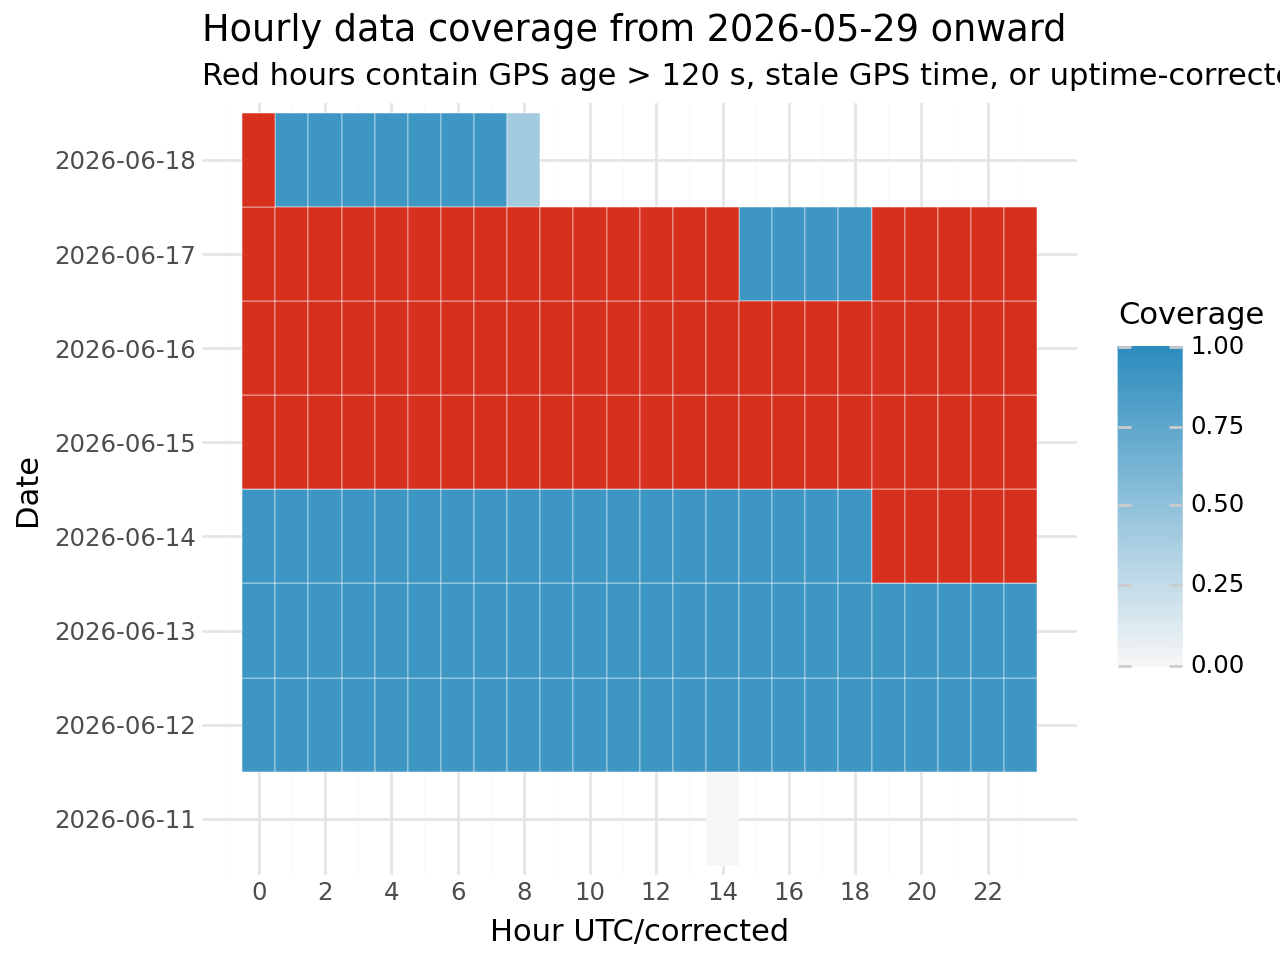

In [10]:
def sensor_long(df: pd.DataFrame, patterns: dict[str, str]) -> pd.DataFrame:
    frames = []
    for raw_col, label in patterns.items():
        if raw_col not in df.columns:
            continue
        tmp = df[["analysis_time", "date", "source_file", raw_col]].copy()
        tmp = tmp.rename(columns={raw_col: "value"})
        tmp["series"] = label
        tmp["value"] = pd.to_numeric(tmp["value"], errors="coerce")
        frames.append(tmp)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def save_plot(plot, filename: str, width: float = 9, height: float = 4.8):
    path = FIG_DIR / filename
    plot.save(path, width=width, height=height, units="in", dpi=150)
    print("saved", path)
    return plot


hourly_coverage = data.groupby(["date", "hour"], as_index=False).agg(
    rows=("analysis_time", "size"),
    unique_timestamps=("analysis_time", "nunique"),
    stale_gps_rows=("gps_time_stale", "sum"),
    corrected_from_uptime_rows=("time_corrected_from_uptime", "sum"),
    max_gps_age_ms=("gps_age_ms", lambda x: pd.to_numeric(x, errors="coerce").max()),
)
hourly_coverage["duplicate_timestamp_rows"] = hourly_coverage["rows"] - hourly_coverage["unique_timestamps"]
hourly_coverage["expected_rows"] = 3600 / EXPECTED_INTERVAL_SECONDS
hourly_coverage["coverage_fraction"] = (hourly_coverage["unique_timestamps"] / hourly_coverage["expected_rows"]).clip(upper=1)
hourly_coverage["stale_gps_fraction"] = hourly_coverage["stale_gps_rows"] / hourly_coverage["rows"]
hourly_coverage["has_stale_gps"] = hourly_coverage["stale_gps_rows"] > 0
stale_hourly_coverage = hourly_coverage[hourly_coverage["has_stale_gps"]].copy()

coverage_plot = (
    ggplot(hourly_coverage, aes("hour", "date", fill="coverage_fraction"))
    + geom_tile(color="white")
    + geom_tile(data=stale_hourly_coverage, mapping=aes("hour", "date"), fill="#d7301f", color="white")
    + scale_fill_gradient(low="#f7f7f7", high="#2b8cbe", limits=(0, 1))
    + scale_x_continuous(breaks=list(range(0, 24, 2)))
    + labs(
        title="Hourly data coverage from 2026-05-29 onward",
        subtitle="Red hours contain GPS age > 120 s, stale GPS time, or uptime-corrected timestamps",
        x="Hour UTC/corrected", y="Date", fill="Coverage"
    )
    + theme_minimal()
)
save_plot(coverage_plot, "hourly_coverage.png")

,source_file,previous_timestamp,analysis_time,gap_minutes
22932,data_20260617.csv,2026-06-17 14:00:19,2026-06-17 14:02:38,2.316667
24775,data_20260618.csv,2026-06-18 00:46:34,2026-06-18 00:49:25,2.850000


C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 9 x 4.8 in image.
C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: figures\inter_sample_gaps.png


saved figures\inter_sample_gaps.png


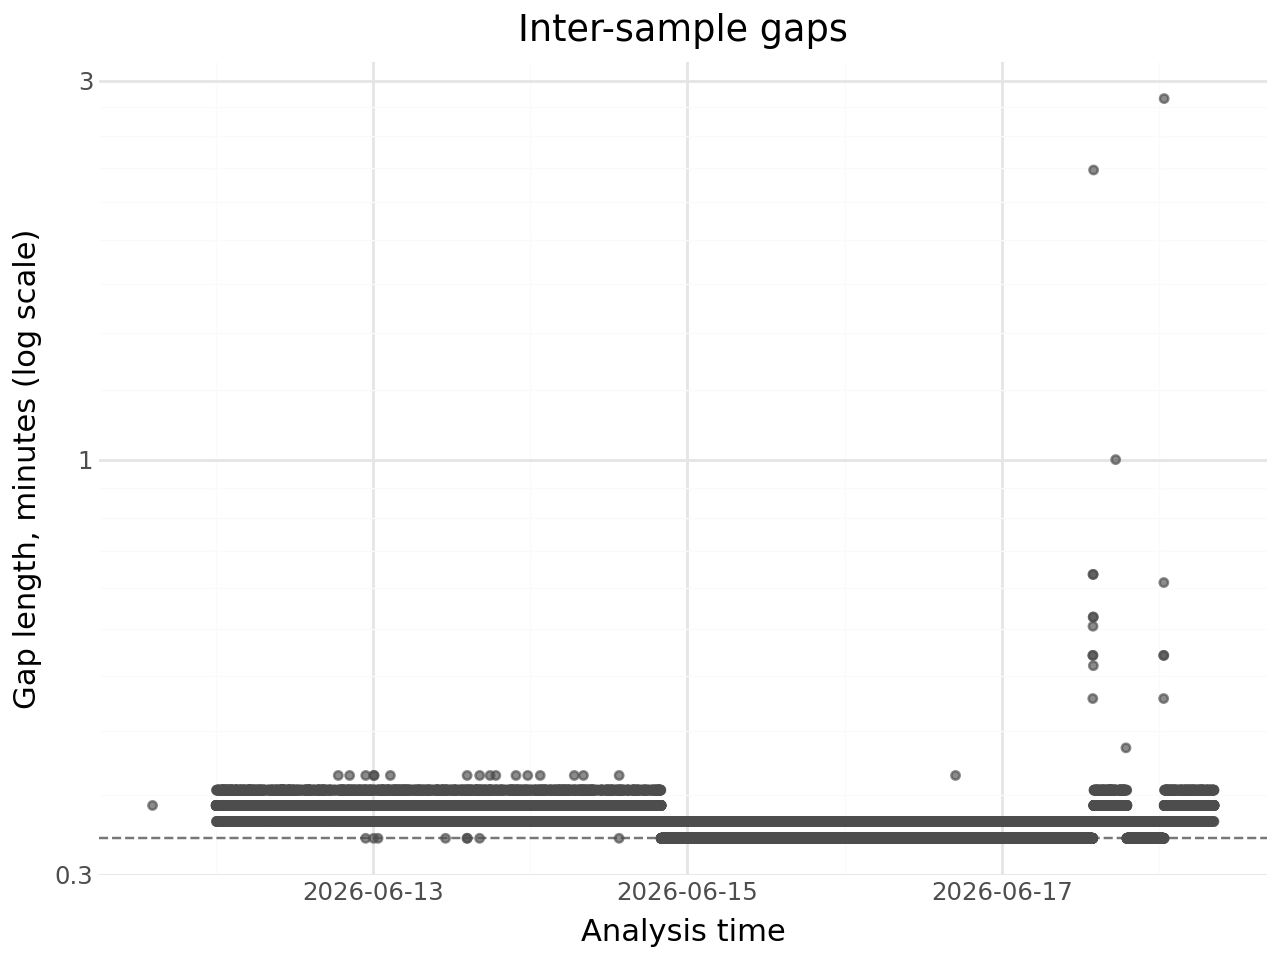

In [11]:
gap_rows = []
for source_file, group in data.groupby("source_file", sort=True):
    ts = group.sort_values("analysis_time")["analysis_time"].reset_index(drop=True)
    gap = pd.DataFrame({
        "source_file": source_file,
        "previous_timestamp": ts.shift(1),
        "analysis_time": ts,
        "delta_seconds": ts.diff().dt.total_seconds(),
    })
    gap_rows.append(gap)
gaps = pd.concat(gap_rows, ignore_index=True)
gaps["gap_minutes"] = gaps["delta_seconds"] / 60
large_gaps = gaps[gaps["delta_seconds"] > 120].copy()
large_gaps["date"] = large_gaps["analysis_time"].dt.strftime("%Y-%m-%d")

gap_plot_data = gaps.dropna(subset=["delta_seconds"]).query("delta_seconds > 0").copy()
gap_plot_data["date"] = gap_plot_data["analysis_time"].dt.strftime("%Y-%m-%d")
gap_plot_data["gap_minutes"] = gap_plot_data["delta_seconds"] / 60

gap_plot = (
    ggplot(gap_plot_data, aes("analysis_time", "gap_minutes"))
    + geom_hline(yintercept=EXPECTED_INTERVAL_SECONDS / 60, color="#777777", linetype="dashed")
    + geom_point(size=1.2, alpha=0.65, color="#4d4d4d")
    + scale_y_log10()
    + labs(title="Inter-sample gaps", x="Analysis time", y="Gap length, minutes (log scale)")
    + theme_minimal()
)
display(large_gaps[["source_file", "previous_timestamp", "analysis_time", "gap_minutes"]])
save_plot(gap_plot, "inter_sample_gaps.png")

,series,n,min_C,median_C,p95_C,max_C
0,BME280 bus0,13186,16.32,21.310,28.350,32.08
1,BME280 bus1,13189,15.72,21.230,30.480,33.75
2,SCD30 bus0,13193,16.87,23.230,32.814,38.16
3,SCD30 bus1,13194,0.00,23.980,36.580,43.49
4,SEN0465 bus0,13186,11.04,51.675,142.390,271.75
5,SEN0465 bus1,13166,17.24,23.980,36.470,154.55


C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 9 x 4.8 in image.
C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: figures\temperature_timeseries.png


saved figures\temperature_timeseries.png


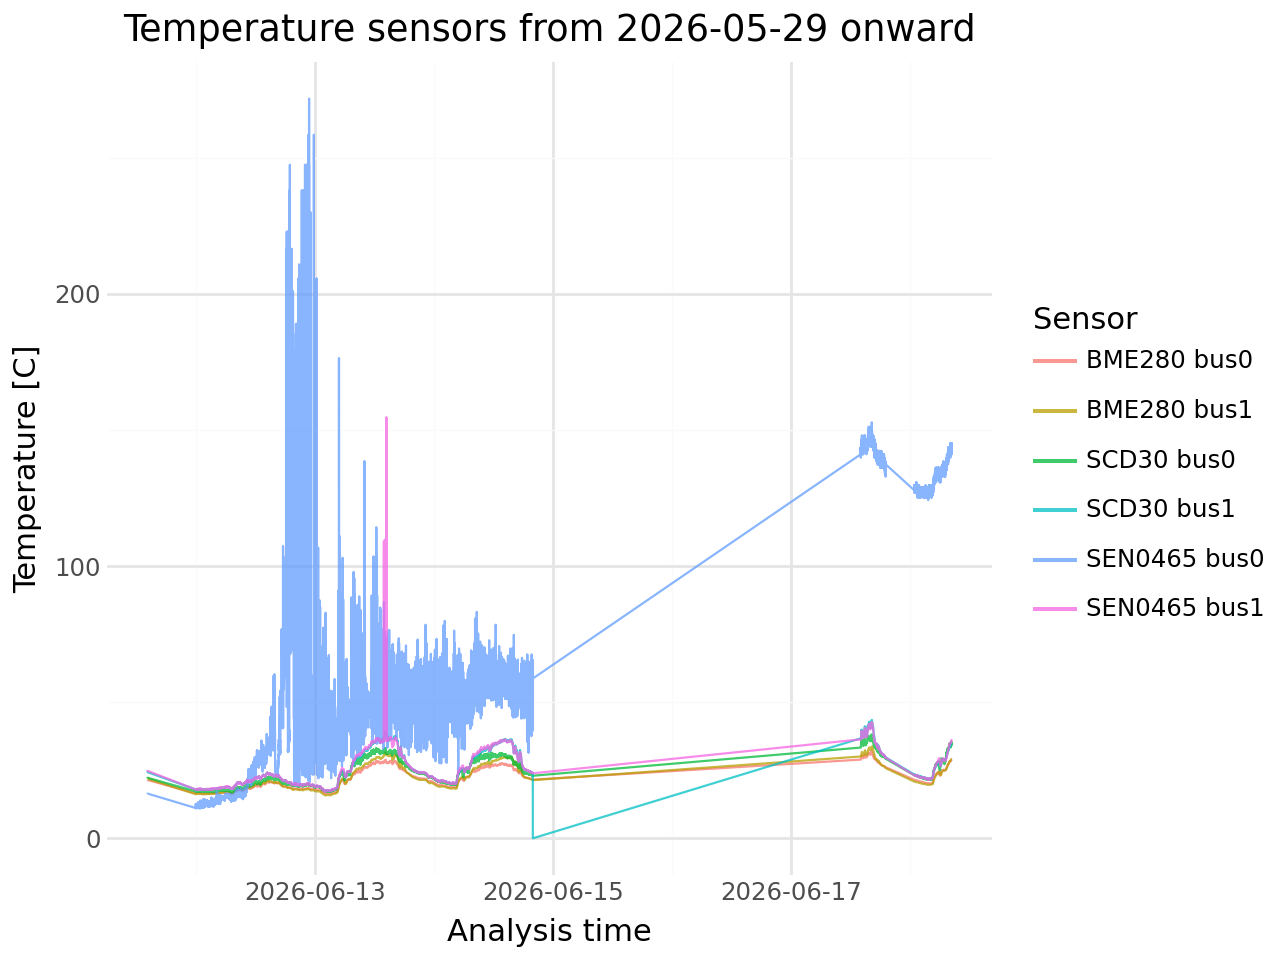

In [12]:
temperature_columns = {
    "bme_T.C__bus0": "BME280 bus0",
    "bme_T.C__bus1": "BME280 bus1",
    "scd_T.C__bus0": "SCD30 bus0",
    "scd_T.C__bus1": "SCD30 bus1",
    "sen_T.C__bus0": "SEN0465 bus0",
    "sen_T.C__bus1": "SEN0465 bus1",
}
temperature_long = sensor_long(data, temperature_columns)
temperature_long.loc[temperature_long["value"] <= -100, "value"] = np.nan
temperature_long = temperature_long.dropna(subset=["value"])

temperature_summary = temperature_long.groupby("series", as_index=False).agg(
    n=("value", "size"),
    min_C=("value", "min"),
    median_C=("value", "median"),
    p95_C=("value", lambda x: x.quantile(0.95)),
    max_C=("value", "max"),
)
display(temperature_summary)

temperature_plot = (
    ggplot(temperature_long, aes("analysis_time", "value", color="series"))
    + geom_line(alpha=0.75, size=0.45)
    + labs(title="Temperature sensors from 2026-05-29 onward", x="Analysis time", y="Temperature [C]", color="Sensor")
    + theme_minimal()
)
save_plot(temperature_plot, "temperature_timeseries.png")

C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 10 x 8 in image.
C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: figures\overview_variables.png


saved figures\overview_variables.png


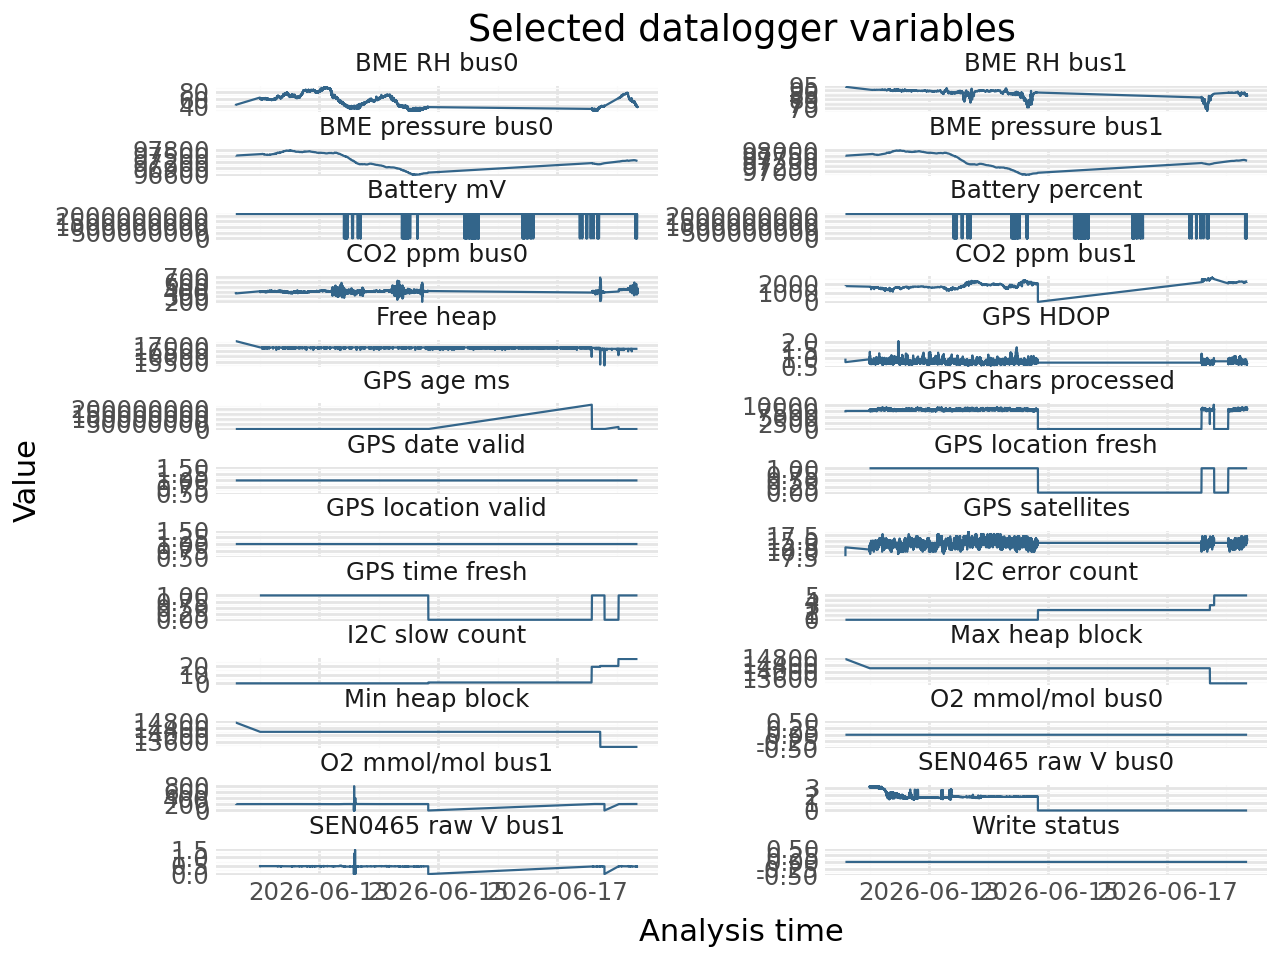

In [13]:
overview_columns = {
    "scd_CO2.ppm__bus0": "CO2 ppm bus0",
    "scd_CO2.ppm__bus1": "CO2 ppm bus1",
    "sen_O2.mmol_mol__bus0": "O2 mmol/mol bus0",
    "sen_O2.mmol_mol__bus1": "O2 mmol/mol bus1",
    "sen_raw_V__bus0": "SEN0465 raw V bus0",
    "sen_raw_V__bus1": "SEN0465 raw V bus1",
    "bme_RH.perc__bus0": "BME RH bus0",
    "bme_RH.perc__bus1": "BME RH bus1",
    "bme_P.Pa__bus0": "BME pressure bus0",
    "bme_P.Pa__bus1": "BME pressure bus1",
    "nb_sat": "GPS satellites",
    "HDOP": "GPS HDOP",
    "bat.mV": "Battery mV",
    "bat.perc": "Battery percent",
    "gps_date_valid": "GPS date valid",
    "gps_time_fresh": "GPS time fresh",
    "gps_location_fresh": "GPS location fresh",
    "gps_location_valid": "GPS location valid",
    "gps_chars_processed": "GPS chars processed",
    "gps_age_ms": "GPS age ms",
    "free_heap": "Free heap",
    "max_heap_block": "Max heap block",
    "min_heap_block": "Min heap block",
    "i2c_slow_count": "I2C slow count",
    "i2c_error_count": "I2C error count",
    "write_status": "Write status",
    "gps_poll_timeout_count": "GPS poll timeouts",
    "gps_i2c_recovery_count": "GPS I2C recoveries",
    "gps_quarantine_active": "GPS quarantine active",
    "gps_quarantine_count": "GPS quarantine count",
    "valid_sensor_value_count": "Valid sensor values",
    "critical_sensor_loss_count": "Critical sensor loss count",
}
overview_long = sensor_long(data, overview_columns).dropna(subset=["value"])

overview_plot = (
    ggplot(overview_long, aes("analysis_time", "value"))
    + geom_line(size=0.45, color="#33658a")
    + facet_wrap("series", scales="free_y", ncol=2)
    + labs(title="Selected datalogger variables", x="Analysis time", y="Value")
    + theme_minimal()
)
save_plot(overview_plot, "overview_variables.png", width=10, height=8)


In [14]:
def nearest_temperature_before_gap(large_gaps: pd.DataFrame, temperature_long: pd.DataFrame, window_minutes: int = 30) -> pd.DataFrame:
    records = []
    for _, gap in large_gaps.iterrows():
        start = gap["previous_timestamp"] - pd.Timedelta(minutes=window_minutes)
        end = gap["previous_timestamp"]
        window = temperature_long[(temperature_long["analysis_time"] >= start) & (temperature_long["analysis_time"] <= end)]
        for series, group in window.groupby("series"):
            records.append({
                "source_file": gap["source_file"],
                "gap_start": gap["previous_timestamp"],
                "gap_end": gap["analysis_time"],
                "gap_minutes": gap["gap_minutes"],
                "series": series,
                "max_temperature_C_before_gap": group["value"].max(),
                "median_temperature_C_before_gap": group["value"].median(),
                "n_temperature_rows": len(group),
            })
    return pd.DataFrame.from_records(records)


overheat_gap_check = nearest_temperature_before_gap(large_gaps, temperature_long)
display(overheat_gap_check.sort_values(["gap_start", "series"]))

if not overheat_gap_check.empty:
    print("Highest temperature observed in the 30 minutes before a >120 s gap:")
    display(overheat_gap_check.sort_values("max_temperature_C_before_gap", ascending=False).head(10))

KeyError: 'gap_start'

In [ ]:
# Robust status loader and GPS/I2C fault classification for June 11+ data.
def status_file_date(path: Path) -> str:
    match = re.fullmatch(r"status_(\d{8})\.csv", path.name)
    return match.group(1) if match else ""


def read_status_file(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path, na_values=["", "nan", "NaN", "NAN"], keep_default_na=True, on_bad_lines="skip")
    frame.insert(0, "source_file", path.name)
    frame.insert(1, "source_date", status_file_date(path))
    return frame


def real_sensor_columns(df: pd.DataFrame) -> list[str]:
    prefixes = ("bme_", "scd_", "sen_", "Sin.", "Sout.", "mlx_")
    blocked = ("flag", ".cal")
    return [col for col in df.columns if col.startswith(prefixes) and not any(token in col for token in blocked)]


status_files = sorted(path for path in DATA_DIR.glob("status_*.csv") if status_file_date(path) >= "20260611")
if status_files:
    status_data = pd.concat([read_status_file(path) for path in status_files], ignore_index=True, sort=False)
    for col in status_data.columns:
        if col not in {"source_file", "source_date", "event", "reset_reason", "CRC16"}:
            status_data[col] = pd.to_numeric(status_data[col], errors="coerce")
    print("Status rows loaded from 2026-06-11 onward:", len(status_data))
    display(status_data.groupby(["source_file", "event"], dropna=False).size().rename("rows").reset_index())
else:
    status_data = pd.DataFrame()
    print("No status_YYYYMMDD.csv files found from 2026-06-11 onward.")

sensor_cols = real_sensor_columns(data)
for col in sensor_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")
if "valid_sensor_value_count" not in data.columns:
    data["valid_sensor_value_count"] = data[sensor_cols].notna().sum(axis=1) if sensor_cols else 0
if "missing_sensor_value_count" not in data.columns:
    data["missing_sensor_value_count"] = data[sensor_cols].isna().sum(axis=1) if sensor_cols else 0

gps_chars = pd.to_numeric(data.get("gps_chars_processed", pd.Series(pd.NA, index=data.index)), errors="coerce")
gps_age = pd.to_numeric(data.get("gps_age_ms", pd.Series(pd.NA, index=data.index)), errors="coerce")
valid_sensor_values = pd.to_numeric(data["valid_sensor_value_count"], errors="coerce").fillna(0)
quarantine = pd.to_numeric(data.get("gps_quarantine_active", pd.Series(0, index=data.index)), errors="coerce").fillna(0).astype(bool)

classified = data.dropna(subset=["analysis_time"]).copy()
classified["gps_chars_zero"] = gps_chars.loc[classified.index].fillna(1).eq(0)
classified["gps_age_too_high"] = gps_age.loc[classified.index].gt(GPS_STALE_THRESHOLD_MS).fillna(False)
classified["sensor_data_lost"] = valid_sensor_values.loc[classified.index].eq(0)
classified["gps_i2c_wedge_suspected"] = classified["sensor_data_lost"] & (
    classified["gps_chars_zero"] | classified["gps_age_too_high"] | quarantine.loc[classified.index]
)
classified["fault_class"] = np.select(
    [
        classified["gps_i2c_wedge_suspected"],
        classified["sensor_data_lost"],
        classified["gps_age_too_high"] | classified["gps_chars_zero"],
    ],
    ["gps_i2c_wedge_suspected", "sensor_data_lost", "gps_stale_only"],
    default="normal",
)

fault_summary = (
    classified.assign(date=lambda x: x["analysis_time"].dt.strftime("%Y-%m-%d"))
    .groupby(["date", "fault_class"], as_index=False)
    .agg(
        rows=("fault_class", "size"),
        first_time=("analysis_time", "min"),
        last_time=("analysis_time", "max"),
        median_valid_sensor_values=("valid_sensor_value_count", "median"),
        max_gps_age_ms=("gps_age_ms", "max"),
    )
)
print("GPS/I2C fault classification summary:")
display(fault_summary)

transitions = classified[[
    "analysis_time", "fault_class", "valid_sensor_value_count",
    "gps_chars_processed", "gps_age_ms", "source_file",
]].copy()
transitions["group"] = transitions["fault_class"].ne(transitions["fault_class"].shift()).cumsum()
fault_intervals = (
    transitions.groupby("group", as_index=False)
    .agg(
        fault_class=("fault_class", "first"),
        start=("analysis_time", "min"),
        end=("analysis_time", "max"),
        rows=("fault_class", "size"),
        min_valid_sensor_values=("valid_sensor_value_count", "min"),
        max_gps_age_ms=("gps_age_ms", "max"),
        first_source_file=("source_file", "first"),
        last_source_file=("source_file", "last"),
    )
)
fault_intervals["duration_minutes"] = (fault_intervals["end"] - fault_intervals["start"]).dt.total_seconds() / 60
fault_intervals = fault_intervals[fault_intervals["fault_class"] != "normal"]
print("Fault intervals:")
display(fault_intervals.sort_values("start"))

if not fault_intervals.empty:
    fault_timeline_plot = (
        ggplot(fault_intervals, aes(x="start", xend="end", y="fault_class", yend="fault_class", color="fault_class"))
        + geom_segment(size=6)
        + scale_color_manual(values={
            "gps_i2c_wedge_suspected": "#d7301f",
            "sensor_data_lost": "#fc8d59",
            "gps_stale_only": "#756bb1",
            "supervisor_restart": "#111111",
        })
        + labs(title="GPS/I2C fault timeline", x="Analysis time", y="Fault class", color="Fault class")
        + theme_minimal()
    )
    save_plot(fault_timeline_plot, "gps_i2c_fault_timeline.png", width=10, height=3.5)
